In [1]:
#!/usr/bin/env python
import sys, glob, os
from pathlib import Path
import numpy as np
import numpy.ma as ma
from matplotlib import pyplot as plt
import MITgcmutils as MIT
import xmitgcm as xmit
import skill_metrics as sm

In [2]:
sys.path.append('/albedo/home/nmamnun/miniconda3/ECCOv4-py')
import ecco_v4_py as ecco

In [6]:
assim_dir = '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/JSPE'
obs_iters = np.arange(736524, 736524+360*73, 360)
obs_schla = []
for iter in obs_iters:
    schla = MIT.rdmds(os.path.join(assim_dir,'schla_'), iter)
    schla = ecco.llc_compact_to_tiles(schla)
    obs_schla.append(schla)
    
obs_schla = np.array(obs_schla)
print(obs_schla.shape)
obs_schla[obs_schla>99.0] = np.nan

llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_c

In [7]:
def load_variable_from_mds(data_dir, prefix, var, iters='all'):
    """
    Load a specific variable from an MDS dataset.

    Parameters:
    - data_dir (str): The directory where the data files are located.
    - prefix (str): The prefix for the data files.
    - var (str): The variable name to load (e.g., 'SALT').
    - iters (str or list): Iteration numbers to load, 'all' by default.

    Returns:
    - xarray.DataArray: The specified variable from the MDS dataset.
    """
    diag = xmit.open_mdsdataset(data_dir=data_dir,
                                  grid_dir='../Grid',
                                  prefix=prefix,
                                  iters=iters,
                                  geometry='llc')
    
    return diag[var]

In [8]:
def_dir= '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/REF_FOR/outputs_2020'
est_dir = '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/ADJ_FOR/outputs_2020'

In [9]:
nanochl_def = load_variable_from_mds(data_dir=def_dir,
                             prefix='recomDiags3D',
                             var='TRAC06')
diachl_def = load_variable_from_mds(data_dir=def_dir,
                             prefix='recomDiags3D',
                             var='TRAC15')
totchl_def = nanochl_def + diachl_def

In [10]:
totchl_surf_def = totchl_def[:,0]
totchl_surf_def.shape

(73, 13, 90, 90)

In [11]:
nanochl_est = load_variable_from_mds(data_dir=est_dir,
                             prefix='recomDiags3D',
                             var='TRAC06')
diachl_est = load_variable_from_mds(data_dir=est_dir,
                             prefix='recomDiags3D',
                             var='TRAC15')
totchl_est = nanochl_est + diachl_est

In [12]:
totchl_surf_est = totchl_est[:,0]
totchl_surf_est.shape

(73, 13, 90, 90)

In [13]:
def calculate_monthly_averages(data_5day):
    num_time_steps, num_tiles, num_lat, num_lon = data_5day.shape
    num_months = 12  
    month_indices = [
        (0, 6), (6, 12), (12, 18), (18, 24), (24, 30), (30, 36),
        (36, 42), (42, 49), (49, 55), (55, 61), (61, 67), (67, 73)
    ]

    monthly_average = np.zeros((num_months, num_tiles, num_lat, num_lon))
    for month_idx, (start_idx, end_idx) in enumerate(month_indices):
        monthly_average[month_idx] = np.nanmean(data_5day[start_idx:end_idx], axis=0)

    return monthly_average

In [14]:
obs_schla_2020_mon = calculate_monthly_averages(obs_schla)
totchl_surf_def_2020_mon = calculate_monthly_averages(totchl_surf_def)
totchl_surf_est_2020_mon = calculate_monthly_averages(totchl_surf_est)

/tmp/ipykernel_239639/3277820127.py:15: RuntimeWarning: Mean of empty slice
  monthly_average[month_idx] = np.nanmean(data_5day[start_idx:end_idx], axis=0)


In [15]:
obs_schla_2020_ana = np.nanmean(obs_schla, axis=0)
totchl_surf_def_2020_ana = np.nanmean(totchl_surf_def, axis=0)
totchl_surf_est_2020_ana = np.nanmean(totchl_surf_est, axis=0)

/tmp/ipykernel_239639/3654951314.py:1: RuntimeWarning: Mean of empty slice
  obs_schla_2020_ana = np.nanmean(obs_schla, axis=0)


In [16]:
assim_dir = '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/JSPE'
obs_iters_2019 = np.arange(710244, 710244+360*73, 360)
obs_schla_2019 = []
for itr in obs_iters_2019:
    schla = MIT.rdmds(os.path.join(assim_dir,'schla_'), itr)
    schla = ecco.llc_compact_to_tiles(schla)
    obs_schla_2019.append(schla)
    
obs_schla_2019 = np.array(obs_schla_2019)
print(obs_schla_2019.shape)
obs_schla_2019[obs_schla_2019>99.0] = np.nan

llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_c

In [17]:
def_dir_2019= '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/REF_FOR/outputs_2019'
est_dir_2019 = '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/ADJ_FOR/outputs_2019'

In [18]:
nanochl_def_2019 = load_variable_from_mds(data_dir=def_dir_2019,
                             prefix='recomDiags3D',
                             var='TRAC06')
diachl_def_2019 = load_variable_from_mds(data_dir=def_dir_2019,
                             prefix='recomDiags3D',
                             var='TRAC15')
totchl_def_2019 = nanochl_def_2019 + diachl_def_2019

In [19]:
totchl_surf_def_2019 = totchl_def_2019[:,0]
totchl_surf_def_2019.shape

(73, 13, 90, 90)

In [20]:
nanochl_est_2019 = load_variable_from_mds(data_dir=est_dir_2019,
                             prefix='recomDiags3D',
                             var='TRAC06')
diachl_est_2019 = load_variable_from_mds(data_dir=est_dir_2019,
                             prefix='recomDiags3D',
                             var='TRAC15')
totchl_est_2019 = nanochl_est_2019 + diachl_est_2019

In [21]:
totchl_surf_est_2019 = totchl_est_2019[:,0]
totchl_surf_est_2019.shape

(73, 13, 90, 90)

In [22]:
obs_schla_2019_mon = calculate_monthly_averages(obs_schla_2019)
totchl_surf_def_2019_mon = calculate_monthly_averages(totchl_surf_def_2019)
totchl_surf_est_2019_mon = calculate_monthly_averages(totchl_surf_est_2019)

/tmp/ipykernel_239639/3277820127.py:15: RuntimeWarning: Mean of empty slice
  monthly_average[month_idx] = np.nanmean(data_5day[start_idx:end_idx], axis=0)


In [23]:
obs_schla_2019_ana = np.nanmean(obs_schla_2019, axis=0)
totchl_surf_def_2019_ana = np.nanmean(totchl_surf_def_2019, axis=0)
totchl_surf_est_2019_ana = np.nanmean(totchl_surf_est_2019, axis=0)

/tmp/ipykernel_239639/1672060348.py:1: RuntimeWarning: Mean of empty slice
  obs_schla_2019_ana = np.nanmean(obs_schla_2019, axis=0)


In [24]:
import xarray as xr
llc90_grid = xr.open_dataset('llc90_grid.nc')
lons = llc90_grid.XC
lats = llc90_grid.YC

In [25]:
if isinstance(lons, xr.core.dataarray.DataArray):
    lons_1d = lons.values.reshape(np.prod(lons.values.shape))
    lats_1d = lats.values.reshape(np.prod(lats.values.shape))
elif isinstance(lons, np.ndarray):
    lons_1d = lons.reshape(np.prod(lons.shape))
    lats_1d = lats.reshape(np.prod(lats.shape))
else:
    print('lons and lats variable either a DataArray or numpy.ndarray')

In [26]:
mask_nh = lats < 0
mask_sh = lats > 0

In [27]:
import copy
totchl_surf_def_nh_2019 = copy.deepcopy(totchl_surf_def_2019) 
totchl_surf_def_sh_2019 = copy.deepcopy(totchl_surf_def_2019) 
totchl_surf_est_nh_2019 = copy.deepcopy(totchl_surf_est_2019) 
totchl_surf_est_sh_2019 = copy.deepcopy(totchl_surf_est_2019) 

obs_schla_nh_2019 = copy.deepcopy(obs_schla_2019) 
obs_schla_sh_2019 = copy.deepcopy(obs_schla_2019) 

In [28]:
totchl_surf_def_2019_apr_nh = totchl_surf_def_2019_mon[4]
totchl_surf_def_2019_apr_nh[mask_nh] = np.nan
totchl_surf_est_2019_apr_nh = totchl_surf_est_2019_mon[4]
totchl_surf_est_2019_apr_nh[mask_nh] = np.nan
obs_schla_2019_apr_nh = obs_schla_2019_mon[4]
obs_schla_2019_apr_nh[mask_nh] = np.nan

In [29]:
totchl_surf_def_2019_sep_sh = totchl_surf_def_2019_mon[8]
totchl_surf_def_2019_sep_sh[mask_sh] = np.nan
totchl_surf_est_2019_sep_sh = totchl_surf_est_2019_mon[8]
totchl_surf_est_2019_sep_sh[mask_sh] = np.nan
obs_schla_2019_sep_sh = obs_schla_2019_mon[8]
obs_schla_2019_sep_sh[mask_sh] = np.nan

In [30]:
def plot_taylor_diagram(predicted_arrays, reference_array, labels,
                        tickRMS=None, colRMS='navy', tickRMSangle=130.0,
                        rmsLabelFormat='0:.2f', markerLegend='on',
                        markerSize = 10, markerColor=None,
                        styleCOR='--', markerLabelColor='k', ax=None):

    sdev, crmsd, ccoef = [], [], []

    # Compute reference statistics
    finite_indices_ref = np.isfinite(reference_array)
    filtered_reference = reference_array[finite_indices_ref]
    taylor_stats1 = sm.taylor_statistics(
        filtered_reference, filtered_reference)

    # Compute statistics for each predicted array
    for predicted in predicted_arrays:
        finite_indices = np.logical_and(np.isfinite(
            predicted), np.isfinite(reference_array))
        filtered_predicted = predicted[finite_indices]
        filtered_reference = reference_array[finite_indices]

        taylor_stats = sm.taylor_statistics(
            filtered_predicted, filtered_reference)
        sdev.append(taylor_stats['sdev'][1])
        crmsd.append(taylor_stats['crmsd'][1])
        ccoef.append(taylor_stats['ccoef'][1])

    # Add reference (observation) statistics
    sdev = [taylor_stats1['sdev'][0]] + sdev
    crmsd = [taylor_stats1['crmsd'][0]] + crmsd
    ccoef = [taylor_stats1['ccoef'][0]] + ccoef

    # Prepare arguments for Taylor Diagram plotting
    taylor_args = {
        'markerLabel': labels,
        'colRMS': colRMS,
        'tickRMSangle': tickRMSangle,
        'rmsLabelFormat': rmsLabelFormat,
        'markerLegend': markerLegend,
        'markerSize': markerSize,
        'markerColor': markerColor,
        'styleCOR': styleCOR,
        'markerLabelColor': markerLabelColor
    }
    if tickRMS is not None:
        taylor_args['tickRMS'] = tickRMS
    # Set current axis if provided
    if ax is not None:
        plt.sca(ax)

    # Plot Taylor Diagram
    sm.taylor_diagram(np.array(sdev), np.array(
        crmsd), np.array(ccoef), **taylor_args)

    # Get current figure and axis
    fig = plt.gcf()
    if ax is None:
        ax = plt.gca()

    return fig, ax

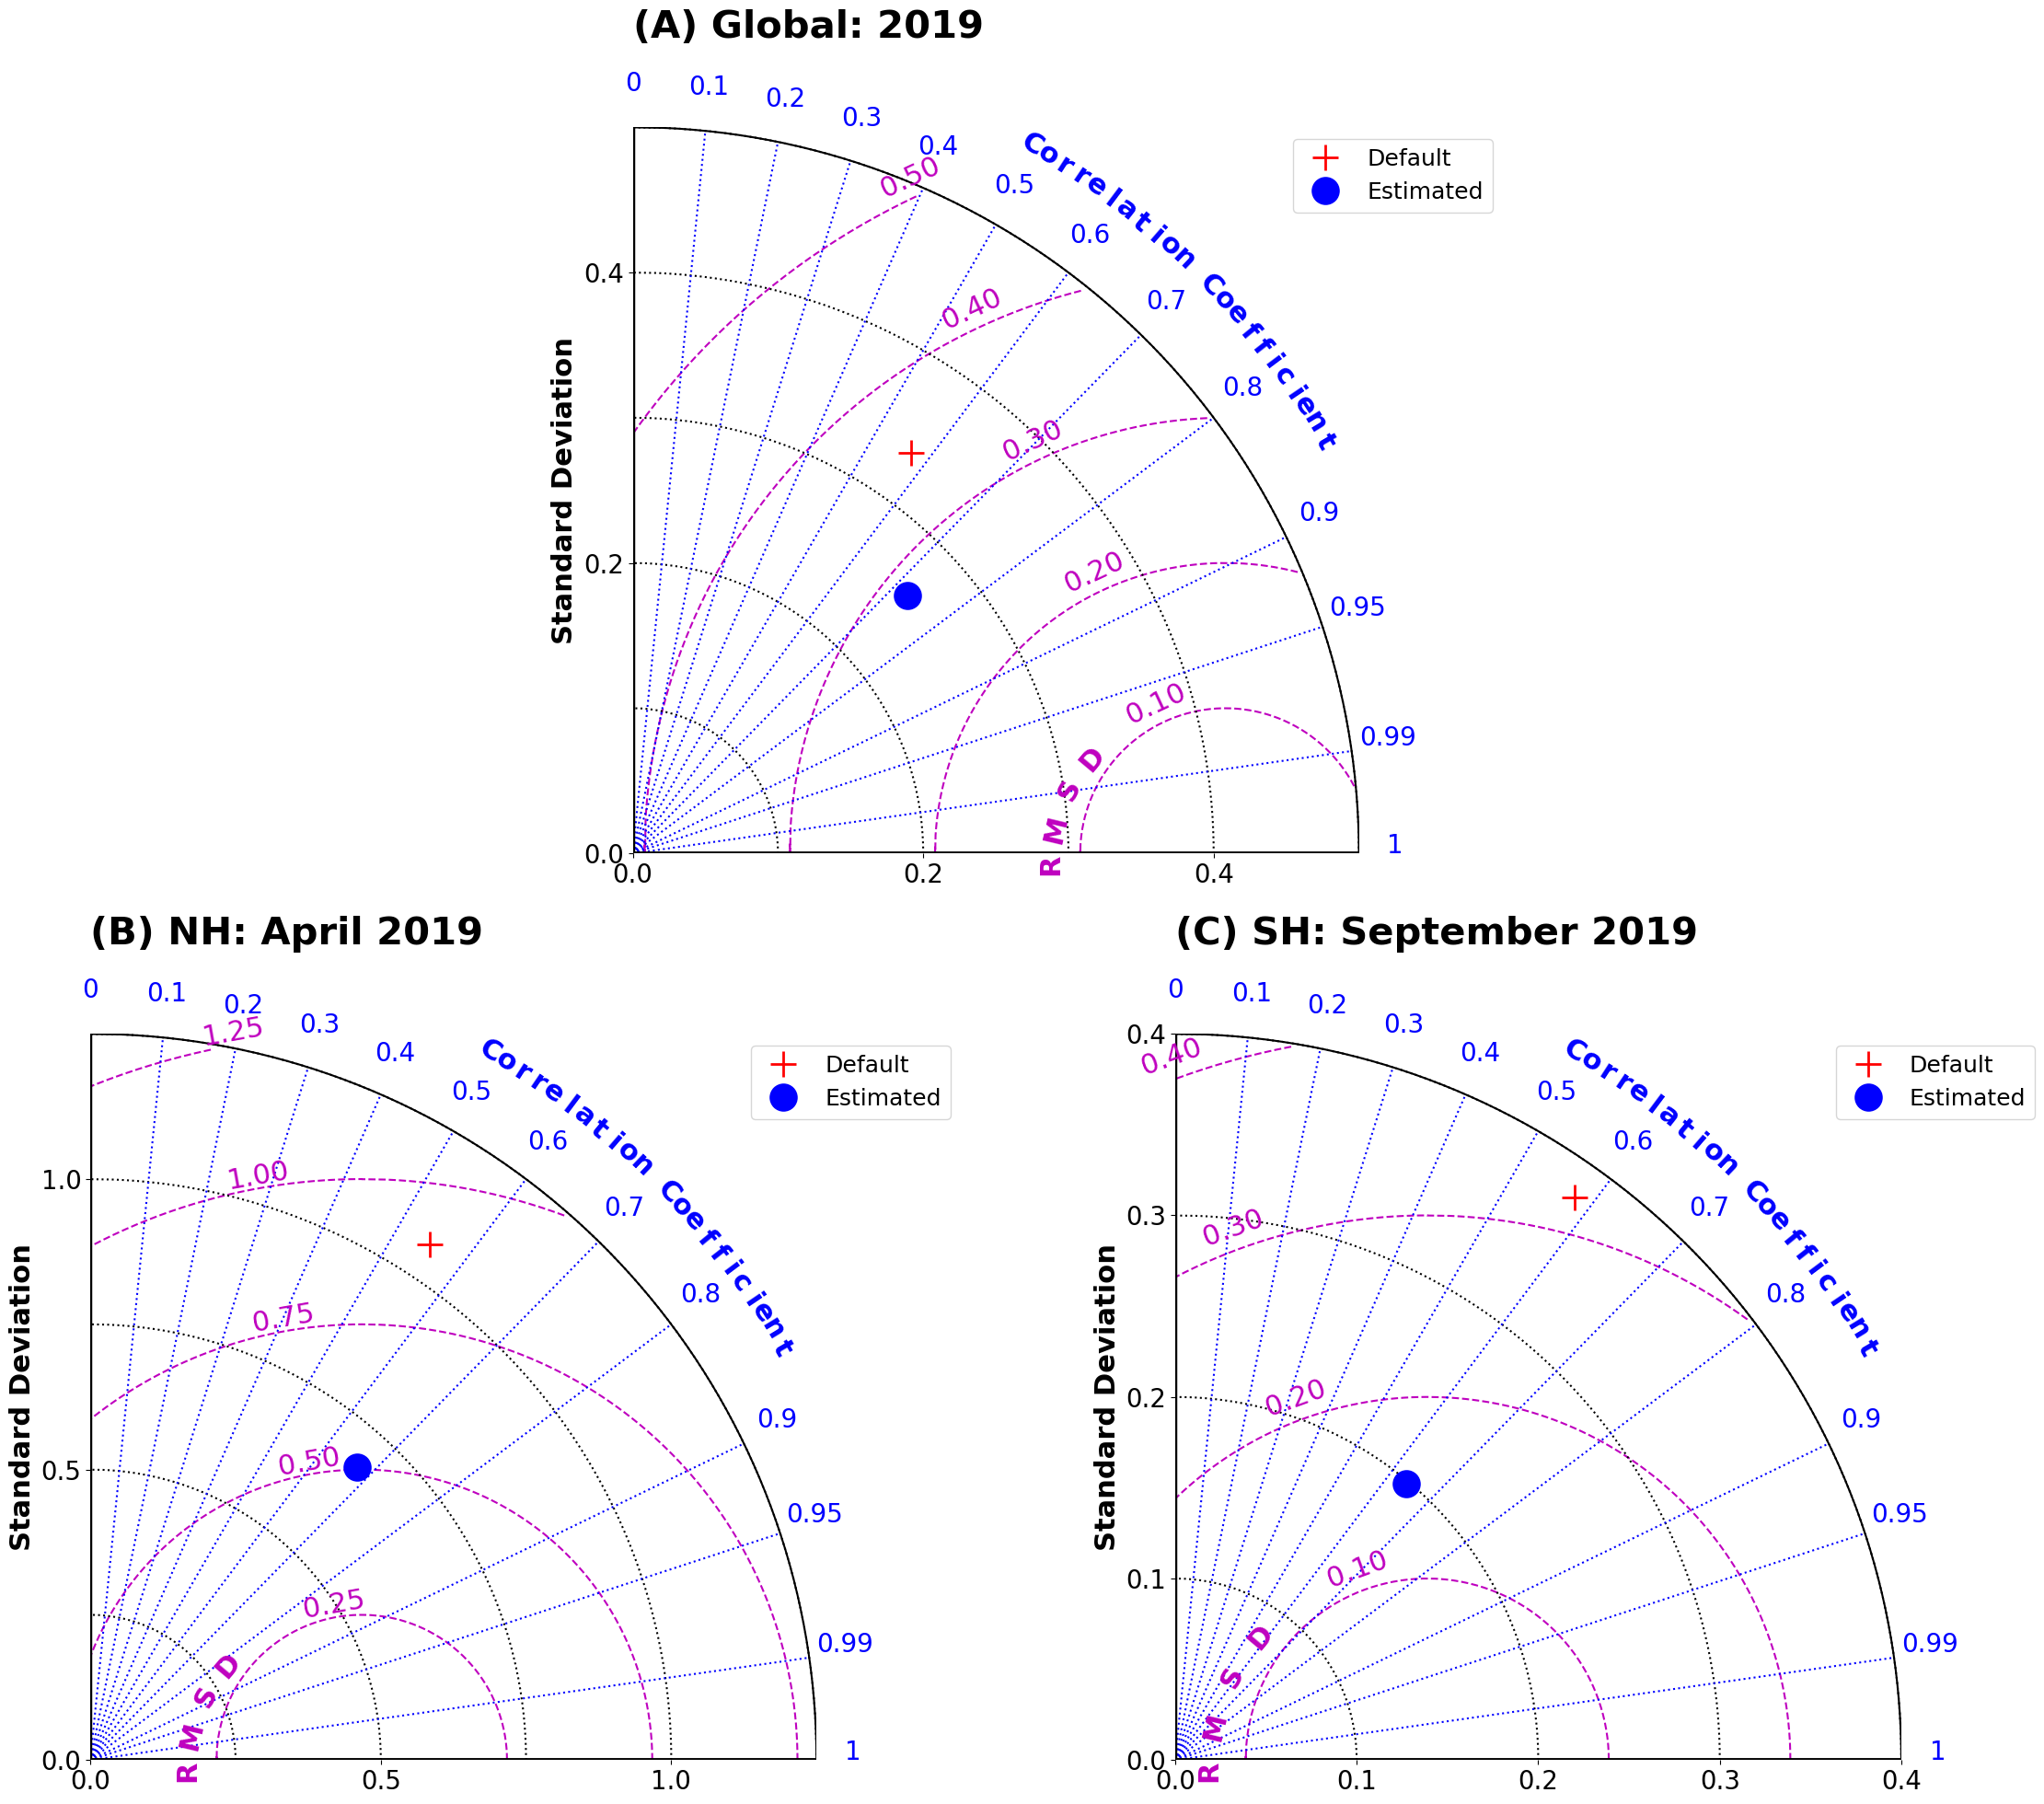

In [31]:
from matplotlib.gridspec import GridSpec

plt.rcParams.update({'font.size': 20})
labels = ['Non-Dimensional Observation', 'Default', 'Estimated']

fig = plt.figure(figsize=(24, 20))
gs = GridSpec(2, 2, figure=fig)

# Subplot A: Full width on top
ax0 = fig.add_subplot(gs[0, :])
predicted_arrays = [totchl_surf_def_2019_ana, totchl_surf_est_2019_ana]
reference_array = obs_schla_2019_ana
plot_taylor_diagram(predicted_arrays, reference_array, labels,
                    tickRMSangle=115., colRMS='m', styleCOR=':', 
                    markerSize=20, ax=ax0)
ax0.set_title("(A) Global: 2019", pad=70, fontweight='bold', fontsize=30, loc='left')

# Subplot B: Bottom left
ax1 = fig.add_subplot(gs[1, 0])
predicted_arrays = [totchl_surf_def_2019_apr_nh, totchl_surf_est_2019_apr_nh]
reference_array = obs_schla_2019_apr_nh
plot_taylor_diagram(predicted_arrays, reference_array, labels,
                    tickRMSangle=100., colRMS='m', styleCOR=':', 
                    markerSize=20, ax=ax1)
ax1.set_title("(B) NH: April 2019", pad=70, fontweight='bold', fontsize=30, loc='left')

# Subplot C: Bottom right
ax2 = fig.add_subplot(gs[1, 1])
predicted_arrays = [totchl_surf_def_2019_sep_sh, totchl_surf_est_2019_sep_sh]
reference_array = obs_schla_2019_sep_sh
plot_taylor_diagram(predicted_arrays, reference_array, labels,
                    tickRMSangle=110., colRMS='m', styleCOR=':', 
                    markerSize=20, ax=ax2)
ax2.set_title("(C) SH: September 2019", pad=70, fontweight='bold', fontsize=30, loc='left')


fig.subplots_adjust(wspace=0.)  
plt.tight_layout()


plt.savefig("Taylor_diagrams.pdf", bbox_inches='tight', dpi=500)


plt.show()